In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
# Estilo general
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (6,4)

In [75]:
# Función para matriz de confusión
import numpy as np

def plot_confusion_matrix(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    
    # calcular porcentajes
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    labels = np.array([
        [f"{cm[0,0]}\n({cm_percent[0,0]*100:.1f}%)", f"{cm[0,1]}\n({cm_percent[0,1]*100:.1f}%)"],
        [f"{cm[1,0]}\n({cm_percent[1,0]*100:.1f}%)", f"{cm[1,1]}\n({cm_percent[1,1]*100:.1f}%)"]
    ])
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=labels, fmt='', cmap=cmap, cbar=True, linewidths=1, linecolor='black')
    
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Predicción", fontsize=11)
    plt.ylabel("Real", fontsize=11)
    
    plt.xticks([0.5, 1.5], ['No fraude', 'Fraude'])
    plt.yticks([0.5, 1.5], ['No fraude', 'Fraude'], rotation=0)
    
    plt.tight_layout()
    plt.show()

In [36]:
# Carga de datos

df = pd.read_csv("data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [19]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
df.isnull().sum().sum()

np.int64(0)

El dataset no presenta valores faltantes, pero en un escenario real evaluaría imputación o eliminación dependiendo del contexto

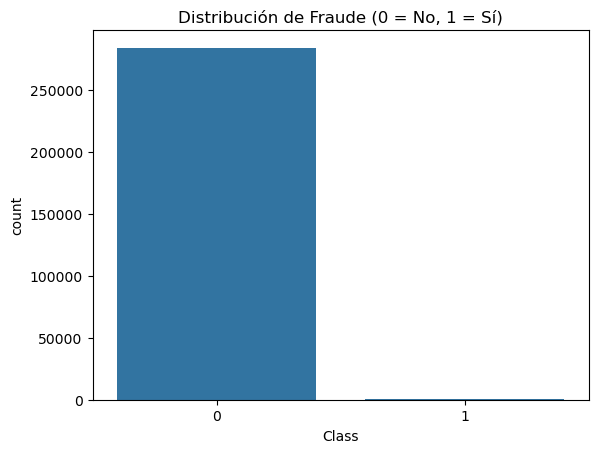

In [37]:
sns.countplot(x='Class', data=df)
plt.title("Distribución de Fraude (0 = No, 1 = Sí)")
plt.show()

Obtenemos un gráfico extremadamente desbalanceado

In [38]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

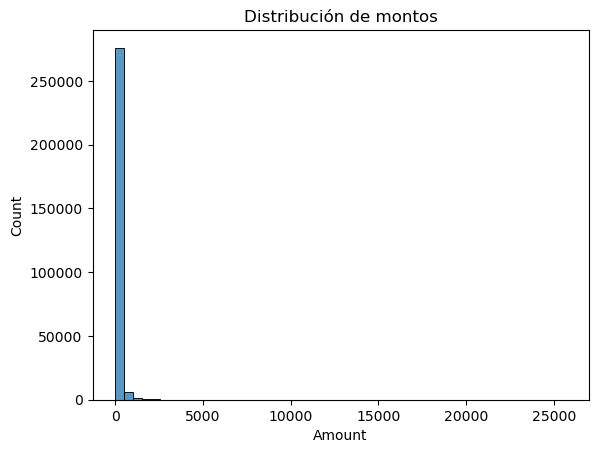

In [39]:
sns.histplot(df['Amount'], bins=50)
plt.title("Distribución de montos")
plt.show()

## Preprocesamiento de datos

In [51]:
# Separar variables - SPLIT
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:
# Escalado (Se recomienda después del split)
scaler = StandardScaler()
X_train[['Amount_scaled','Time_scaled']] = scaler.fit_transform(X_train[['Amount','Time']])
X_test[['Amount_scaled','Time_scaled']] = scaler.transform(X_test[['Amount','Time']])

X_train = X_train.drop(['Amount','Time'], axis=1)
X_test = X_test.drop(['Amount','Time'], axis=1)

In [53]:
# MODELO 1 - BÁSICO
model_lr_base = LogisticRegression(max_iter=3000, solver='liblinear', random_state=42)
model_lr_base.fit(X_train, y_train)

# PREDICCIÓN
y_pred_base = model_lr_base.predict(X_test)
y_proba_base = model_lr_base.predict_proba(X_test)[:,1]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9575306065025898


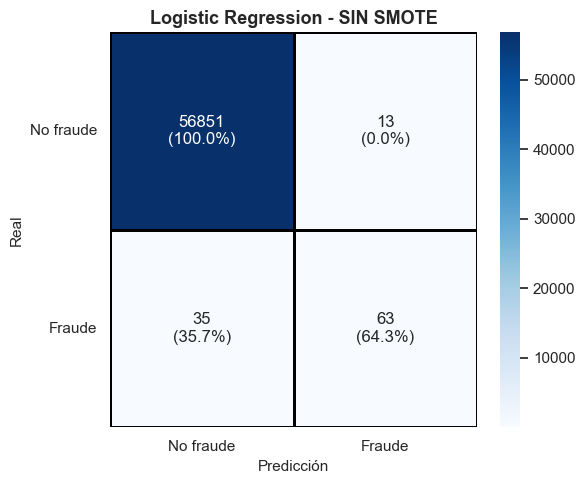

In [72]:
# EVALUACIÓN BASE
print(classification_report(y_test, y_pred_base)) # y_test: respuesta real /
print("ROC-AUC:", roc_auc_score(y_test, y_proba_base))

plot_confusion_matrix(
    y_test, y_pred_base,
    "Logistic Regression - SIN SMOTE",
    cmap="Blues"
)
plt.show()

El modelo presenta una buena precisión en la detección de fraude, sin embargo, su recall es bajo (0.64), lo que implica que una proporción significativa de fraudes no está siendo detectada. En este contexto, mejorar el recall es prioritario, incluso a costa de una leve disminución en precisión.

In [76]:
# SMOTE - SOLO sobre TRAIN
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
y_train_res.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [77]:
# MODELO 2- CON SMOTE
model_lr_smote = LogisticRegression(max_iter=3000, solver='liblinear', random_state=42)

model_lr_smote.fit(X_train_res, y_train_res)

y_pred_smote = model_lr_smote.predict(X_test)
y_proba_smote = model_lr_smote.predict_proba(X_test)[:,1]

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC: 0.9699110229347787


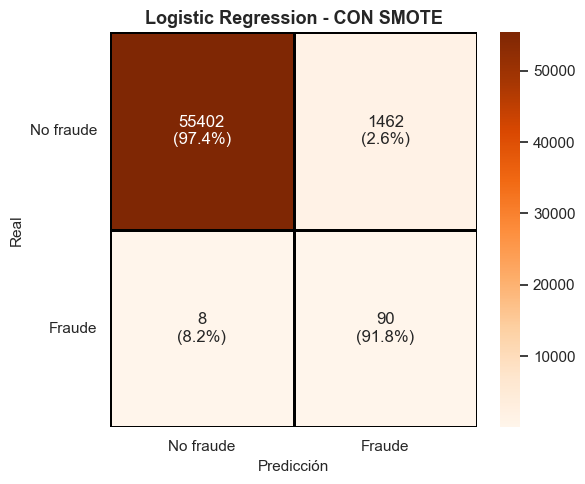

In [96]:
# EVALUACIÓN
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_smote))

plot_confusion_matrix(
    y_test, y_pred_smote,
    "Logistic Regression - CON SMOTE",
    cmap="Oranges"
)
plt.show()

La aplicación de SMOTE permitió aumentar significativamente el recall en la detección de fraude (0.64 → 0.92), reduciendo la cantidad de fraudes no detectados. Sin embargo, esto generó una fuerte caída en la precisión (0.83 → 0.06), aumentando considerablemente los falsos positivos. La elección del modelo dependerá del contexto del negocio y del costo asociado a cada tipo de error.

In [ ]:
# COMPARACIÓN
from sklearn.metrics import precision_score, recall_score

results = pd.DataFrame({
    'Modelo': ['LR Base', 'LR SMOTE'],
    'Recall': [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_smote)
    ],
    'Precision': [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_smote)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba_base),
        roc_auc_score(y_test, y_proba_smote)
    ]
})

results

,Modelo,Recall,Precision,ROC-AUC
0,LR Base,0.642857,0.828947,0.957531
1,LR SMOTE,0.918367,0.057952,0.969928


**U M B R A L**
El umbral decide desde qué probabilidad el modelo dice “fraude”.
Actualmente es 0.5

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Funcion para evaluar umbrales
def evaluar_umbral(y_test, y_proba, umbral):
    y_pred_umbral = (y_proba >= umbral).astype(int)
    
    precision = precision_score(y_test, y_pred_umbral)
    recall = recall_score(y_test, y_pred_umbral)
    f1 = f1_score(y_test, y_pred_umbral)
    
    return precision, recall, f1

In [ ]:
umbrales = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9] # Probamos varios umbrales

resultados_umbral = []

for u in umbrales:
    precision, recall, f1 = evaluar_umbral(y_test, y_proba_smote, u)
    
    resultados_umbral.append({
        'Umbral': u,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

df_umbral = pd.DataFrame(resultados_umbral)
df_umbral

,Umbral,Precision,Recall,F1-score
0,0.1,0.008365,0.948980,0.016583
1,0.2,0.016231,0.918367,0.031898
2,0.3,0.027264,0.918367,0.052957
3,0.4,0.041209,0.918367,0.078878
4,0.5,0.057952,0.918367,0.109025
5,0.6,0.077922,0.918367,0.143655
6,0.7,0.103651,0.897959,0.185850
7,0.8,0.141026,0.897959,0.243767
8,0.9,0.195506,0.887755,0.320442


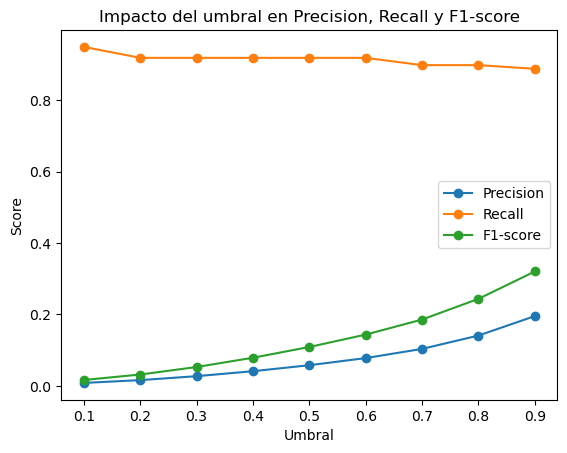

In [ ]:
plt.plot(df_umbral['Umbral'], df_umbral['Precision'], marker='o', label='Precision')
plt.plot(df_umbral['Umbral'], df_umbral['Recall'], marker='o', label='Recall')
plt.plot(df_umbral['Umbral'], df_umbral['F1-score'], marker='o', label='F1-score')

plt.xlabel('Umbral')
plt.ylabel('Score')
plt.title('Impacto del umbral en Precision, Recall y F1-score')
plt.legend()
plt.show()

## Interpretación 
Presición (azul) - Sube cuando sube el umbral / Significa: menos falsos positivos <br>
Recall(naranjo) - Baja levemente aunque sigue alto (~0.9) / El modelo sigue detectando la mayoría de los fraudes<br>
F1-score - Mejora cuando subes el umbral / Balance entre precision

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.90      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.62     56962
weighted avg       1.00      0.99      0.99     56962



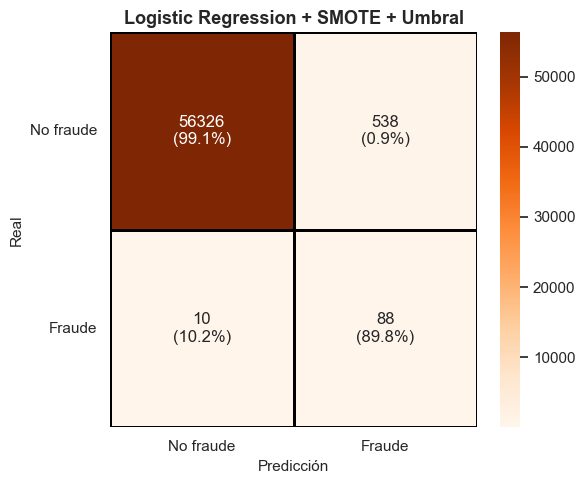

In [98]:
# Aplicamos un umbral de 0.8
y_pred_opt = (y_proba_smote >= 0.8).astype(int)

# Evaluamos el resultado
print(classification_report(y_test, y_pred_opt))

plot_confusion_matrix(
    y_test, y_pred_opt,
    "Logistic Regression + SMOTE + Umbral",
    cmap="Oranges"
)

Fraudes(lo importante)
* 88 detectados
* 10 se escaparon de la detección

Falsos positivos = 536
* Bajaron fuertemente (en el modelo anterior fue de ~1461 con umbral 0.5)

Precision = 0.14
* Si bien sigue baja, es mejor que 0.06 (con SMOTE sin ajustar) y tiene un costo operativo más controlado

## Conclusión
Ajustar el umbral a 0.8 permitió reducir significativamente los falsos positivos manteniendo un alto nivel de detección de fraude (recall 0.90). Esto genera un modelo más equilibrado, adecuado para entornos donde se busca minimizar pérdidas sin generar una sobrecarga excesiva de revisiones manuales.

# RANDOM FOREST

In [57]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train_res, y_train_res)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

In [58]:
y_pred_rf_opt = (y_proba_rf >= 0.8).astype(int) # Aplicamos umbral en 0.8

In [59]:
# EVALUACIÓN
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_test, y_pred_rf_opt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9688195357630954


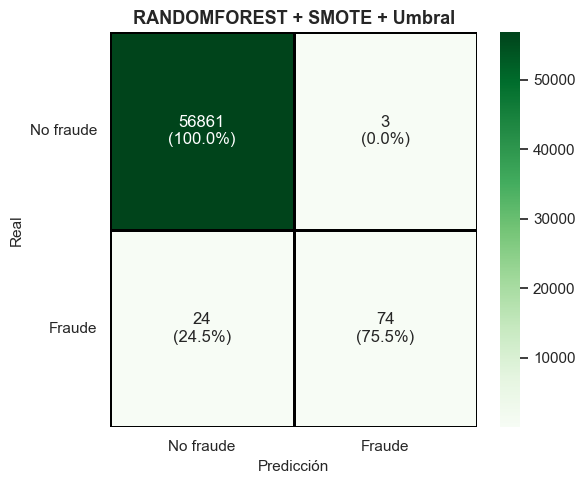

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_confusion_matrix(
    y_test, y_pred_rf_opt,
    "RANDOMFOREST + SMOTE + Umbral",
    cmap="Greens"
)

El modelo Random Forest presenta una alta precisión (0.96), reduciendo significativamente los falsos positivos, lo que lo hace adecuado para entornos productivos donde el costo de alertas incorrectas es alto. Sin embargo, presenta un menor recall en comparación con el modelo basado en regresión logística con SMOTE, lo que implica que algunos fraudes no serán detectados. La elección final depende del equilibrio entre riesgo y costo operativo.

<Figure size 700x500 with 0 Axes>

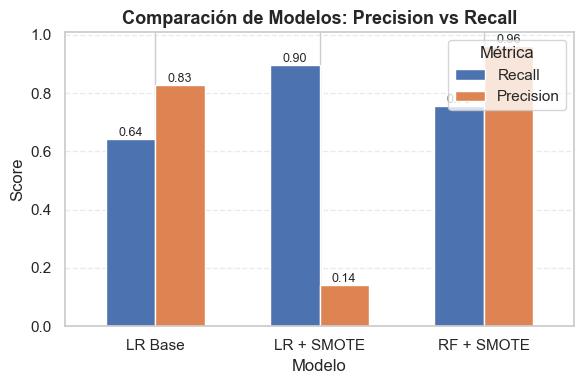

In [93]:
plt.figure(figsize=(7,5))

ax = results.set_index('Modelo').plot(
    kind='bar',
    width=0.6
)

plt.title("Comparación de Modelos: Precision vs Recall", fontsize=13, fontweight='bold')
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.xticks(rotation=0)

# etiquetas sobre las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.legend(title="Métrica", loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

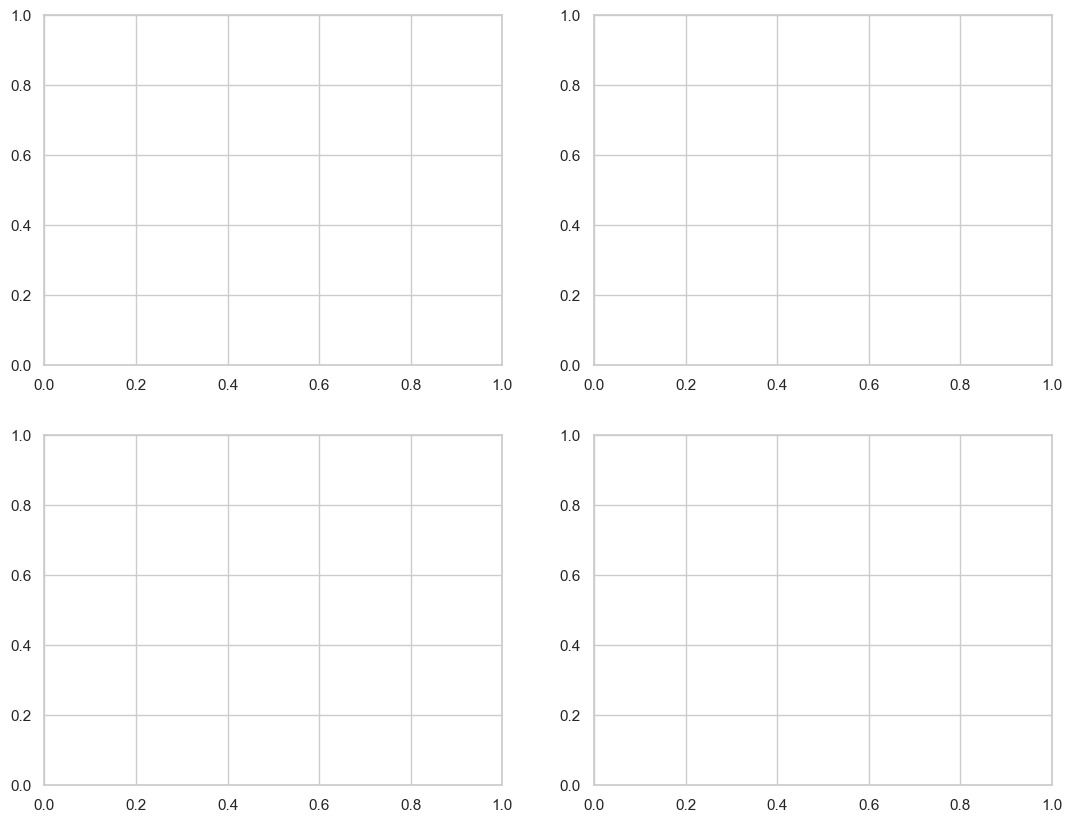

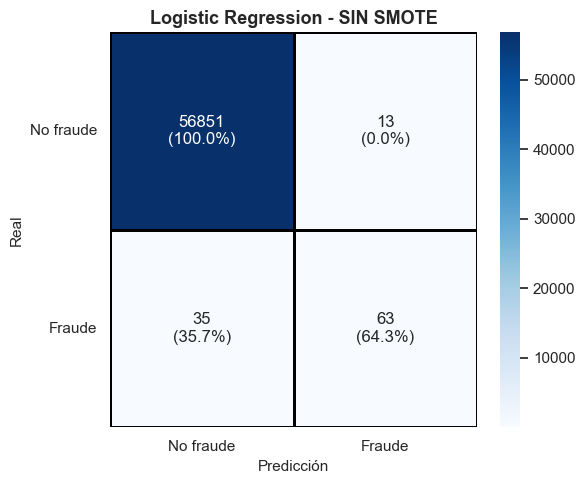

<Figure size 600x400 with 0 Axes>

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. LR Base
sns.heatmap(
    confusion_matrix(y_test, y_pred_base),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0, 0],
    cbar=False
)
axes[0, 0].set_title("LR Base", fontweight='bold')
axes[0, 0].set_xlabel("Predicho")
axes[0, 0].set_ylabel("Real")

# 2. LR + SMOTE + umbral
sns.heatmap(
    confusion_matrix(y_test, y_pred_opt),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[0, 1],
    cbar=False
)
axes[0, 1].set_title("LR + SMOTE + Umbral 0.8", fontweight='bold')
axes[0, 1].set_xlabel("Predicho")
axes[0, 1].set_ylabel("Real")

# 3. Random Forest + SMOTE + umbral
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf_opt),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1, 0],
    cbar=False
)
axes[1, 0].set_title("Random Forest + SMOTE + Umbral 0.8", fontweight='bold')
axes[1, 0].set_xlabel("Predicho")
axes[1, 0].set_ylabel("Real")

# 4. Comparación Precision vs Recall
ax = results.set_index('Modelo').plot(
    kind='bar',
    width=0.65,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Comparación de Modelos", fontweight='bold')
axes[1, 1].set_ylabel("Score")
axes[1, 1].set_xlabel("Modelo")
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.4)
axes[1, 1].legend(title="Métrica")

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=9)

plt.suptitle(
    "Evaluación de Modelos para Detección de Fraude",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

* Los modelos presentan un claro trade-off entre precision y recall.
* La Regresión Logística sin balanceo ofrece alta precisión, pero falla en detectar una cantidad importante de fraudes.
* Al aplicar SMOTE, se mejora significativamente el recall, permitiendo detectar la mayoría de los fraudes, aunque con un aumento considerable de falsos positivos.
* El modelo Random Forest con SMOTE logra el mejor equilibrio, manteniendo una alta precisión (0.96) y un recall aceptable (0.76), lo que lo posiciona como la mejor alternativa para escenarios * productivos donde se busca minimizar falsas alertas sin perder completamente la capacidad de detección.

Random Forest + SMOTE presenta el mejor balance operativo: mantiene una precisión muy alta, reduciendo casi por completo los falsos positivos, aunque detecta menos fraudes que la Regresión Logística con SMOTE. En un entorno productivo, este modelo sería más estable si el costo de revisar falsas alertas es alto.